In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
df = pd.read_csv("moviess.csv", encoding="latin1")

In [34]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset:
(15509, 10)

Column names:
['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 2.3 MB
None

Missing values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [35]:
df.columns = df.columns.str.strip()

In [36]:
print(df.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [37]:
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)


Shape after removing duplicates:
(15503, 10)


In [38]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [39]:
df = df.dropna(subset=["Rating"])


In [40]:
print(df["Rating"].describe())

count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64


In [41]:
if "Year" in df.columns:
    df["Year"] = (
        df["Year"]
        .astype(str)
        .str.extract(r"(\d{4})")[0]
    )

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")


In [42]:
if "Duration" in df.columns:
    df["Duration"] = (
        df["Duration"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
    )

    df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")

In [43]:
if "Votes" in df.columns:
    df["Votes"] = (
        df["Votes"]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")



In [44]:
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


                                 Name  Year  Duration  \
1  #Gadhvi (He thought he was Gandhi)  2019     109.0   
3                             #Yaaram  2019     110.0   
5                ...Aur Pyaar Ho Gaya  1997     147.0   
6                           ...Yahaan  2005     142.0   
8                  ?: A Question Mark  2012      82.0   

                       Genre  Rating  Votes        Director          Actor 1  \
1                      Drama     7.0      8   Gaurav Bakshi     Rasika Dugal   
3            Comedy, Romance     4.4     35      Ovais Khan          Prateik   
5     Comedy, Drama, Musical     4.7    827    Rahul Rawail       Bobby Deol   
6        Drama, Romance, War     7.4   1086  Shoojit Sircar  Jimmy Sheirgill   
8  Horror, Mystery, Thriller     5.6    326   Allyson Patel        Yash Dave   

                  Actor 2          Actor 3  
1          Vivek Ghamande    Arvind Jangid  
3              Ishita Raj  Siddhant Kapoor  
5  Aishwarya Rai Bachchan    Shammi Kapoo

In [45]:
features = [
    "Year",
    "Duration",
    "Votes",
    "Genre",
    "Director",
    "Actor 1",
    "Actor 2",
    "Actor 3"
]
X = df[features]
y = df["Rating"]

print("Features used:")
print(features)

print("\nTarget:")
print("Rating")

Features used:
['Year', 'Duration', 'Votes', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

Target:
Rating


In [46]:
numeric_features = [
    col for col in ["Year", "Duration", "Votes"]
    if col in X.columns
]

categorical_features = [
    col for col in ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]
    if col in X.columns
]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)


Numerical features: ['Year', 'Duration', 'Votes']
Categorical features: ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (6335, 8)
Testing data: (1584, 8)


In [48]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=2
        ))
    ]
)

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [50]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=10.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)


In [51]:
ridge_mae = mean_absolute_error(y_test, ridge_predictions)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_predictions)
)

ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression Results")
print("------------------------")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression Results
------------------------
MAE : 0.9167830824020226
RMSE: 1.1658500064934847
R2 Score: 0.2689079470303727


In [52]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            min_samples_leaf=2
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

In [53]:

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)



Random Forest Regression Results
--------------------------------
MAE : 0.8237247101476899
RMSE: 1.0982595369815666
R2 Score: 0.3512211692336721


In [54]:
results = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        ridge_mae,
        rf_mae
    ],
    "RMSE": [
        ridge_rmse,
        rf_rmse
    ],
    "R2 Score": [
        ridge_r2,
        rf_r2
    ]
})

print(results)

                      Model       MAE     RMSE  R2 Score
0          Ridge Regression  0.916783  1.16585  0.268908
1  Random Forest Regression  0.823725  1.09826  0.351221


In [55]:
if rf_mae < ridge_mae:
    final_model = random_forest_model
    print("Random Forest selected as the final model.")
else:
    final_model = ridge_model
    print("Ridge Regression selected as the final model.")



Random Forest selected as the final model.


In [56]:
new_movie = pd.DataFrame({
    "Year": [2024],
    "Duration": [130],
    "Votes": [50000],
    "Genre": ["Drama"],
    "Director": ["Rajkumar Hirani"],
    "Actor 1": ["Ranbir Kapoor"],
    "Actor 2": ["Vicky Kaushal"],
    "Actor 3": ["Alia Bhatt"]
})
new_movie = new_movie[features]
predicted_rating = final_model.predict(new_movie)

print("Predicted Movie Rating:",
      round(predicted_rating[0], 2))


Predicted Movie Rating: 5.61


In [57]:
new_movie = pd.DataFrame({
    "Year": [2024],
    "Duration": [130],
    "Votes": [50000],
    "Genre": ["Drama"],
    "Director": ["Rajkumar Hirani"],
    "Actor 1": ["Ranbir Kapoor"],
    "Actor 2": ["Vicky Kaushal"],
    "Actor 3": ["Alia Bhatt"]
})
new_movie = new_movie[features]

predicted_rating = final_model.predict(new_movie)[0]

print("Predicted Movie Rating:", round(predicted_rating, 2))


Predicted Movie Rating: 5.61


In [58]:
comparison = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": rf_predictions
})

print(comparison.head(20))


comparison = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": ridge_predictions
})

print(comparison.head(20))

    Actual Rating  Predicted Rating
0             3.3          3.810476
1             5.3          5.117784
2             5.7          5.206511
3             7.2          5.300300
4             3.5          5.228713
5             7.2          6.083681
6             3.8          4.808357
7             6.9          6.966610
8             5.2          5.413786
9             7.4          6.074948
10            4.3          4.983829
11            7.2          7.071010
12            5.6          5.533076
13            3.9          5.418726
14            3.2          4.896086
15            6.4          4.907623
16            5.8          5.542595
17            6.4          5.916279
18            7.6          7.308556
19            2.9          4.820555
    Actual Rating  Predicted Rating
0             3.3          5.060959
1             5.3          5.712681
2             5.7          5.155190
3             7.2          6.073986
4             3.5          4.538457
5             7.2          5

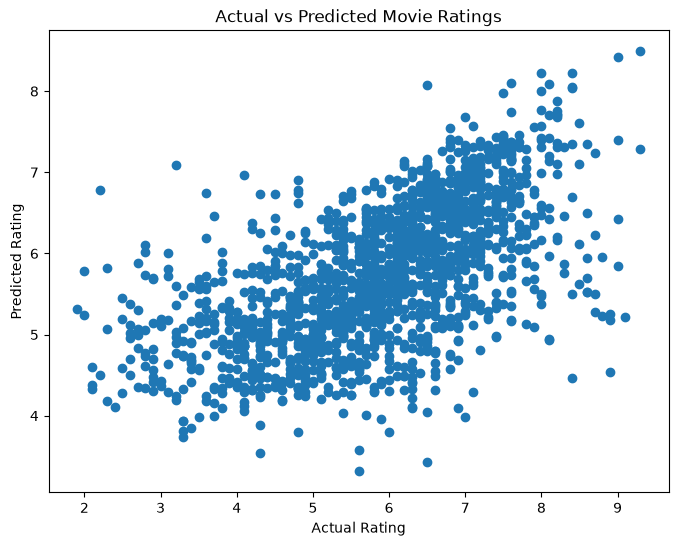

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")

plt.show()


In [62]:
import joblib

joblib.dump(final_model, "movie_rating_model.pkl")

print("Model saved successfully!")



loaded_model = joblib.load("movie_rating_model.pkl")


Model saved successfully!
